In [6]:
import os
import glob
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, Input, mixed_precision
from sklearn.model_selection import train_test_split

# ─────────────────────────────────────────────────────────────────────────────
# ⚙️ GLOBAL CONFIGURATIONS & HYPERPARAMETERS
# ─────────────────────────────────────────────────────────────────────────────
IMG_SIZE = 256  # Standardized input resolution for both phases
BATCH_SIZE = 4
EPOCHS_PHASE1 = 100  # Semantic Segmentation Focus
EPOCHS_PHASE2 = 30   # Segmentation-Based Classification Focus

# Directory and Artifact Paths
DATA_PATH = '/mnt/c/development/Thesis/PolypSegmentationBasedClassification/DataSets/PolypGen2021_MultiCenterData_v2'
POSITIVE_DIR = os.path.join(DATA_PATH, 'imagesAll_positive')
NEGATIVE_DIR = os.path.join(DATA_PATH, 'sequenceData/negativeOnly')
MODEL_SAVE_PATH = "/mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unified_net/thesis_v3_sequential.keras"

# Activate mixed precision training for efficiency and memory optimization
mixed_precision.set_global_policy('mixed_float16')

# ─────────────────────────────────────────────────────────────────────────────
# 📊 STABLE DATA PIPELINE ENGINE (DATASET A & DATASET B)
# ─────────────────────────────────────────────────────────────────────────────

def augment(img, mask):
    """Applies shape-preserving geometric and radiometric transformations."""
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
    img = tf.clip_by_value(img, 0.0, 1.0)
    
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    mask.set_shape([IMG_SIZE, IMG_SIZE, 1])
    return img, mask

def process_path_segmentation(img_path, mask_path):
    """Preprocesses input frames and localized binary masks for Dataset B."""
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_image(mask, channels=1, expand_animations=False)
    mask = tf.image.resize(mask, [IMG_SIZE, IMG_SIZE], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    mask = tf.cast(mask, tf.float32) / 255.0
    mask = tf.where(mask > 0.5, 1.0, 0.0)
    mask.set_shape([IMG_SIZE, IMG_SIZE, 1])
    return img, mask

def process_path_classification(img_path, label):
    """Preprocesses input tensors and categorical targets for Dataset A."""
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    return img, label

def load_segmentation_paths(base_path):
    """Extracts paired image and mask absolute paths from multi-center repositories."""
    all_images, all_masks = [], []
    for i in range(1, 7):
        center_id = f"C{i}"
        img_dir = os.path.join(base_path, f"data_{center_id}", f"images_{center_id}")
        mask_dir = os.path.join(base_path, f"data_{center_id}", f"masks_{center_id}")
        if os.path.exists(img_dir) and os.path.exists(mask_dir):
            img_paths = (glob.glob(os.path.join(img_dir, "*.jpg")) + glob.glob(os.path.join(img_dir, "*.JPG")) +
                         glob.glob(os.path.join(img_dir, "*.png")) + glob.glob(os.path.join(img_dir, "*.jpeg")))
            for img_p in img_paths:
                filename = os.path.basename(img_p)
                name_without_ext, ext = os.path.splitext(filename)
                expected_mask_name = f"{name_without_ext}_mask{ext}"
                mask_p = os.path.join(mask_dir, expected_mask_name)
                if os.path.exists(mask_p):
                    all_images.append(img_p)
                    all_masks.append(mask_p)
    return all_images, all_masks

def load_classification_paths():
    """Compiles absolute paths for global positive and artifact-heavy negative sequences."""
    valid_exts = ('*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tif', '*.PNG', '*.JPG', '*.JPEG')
    pos_files, neg_files = [], []
    for ext in valid_exts:
        pos_files.extend(glob.glob(os.path.join(POSITIVE_DIR, "**", ext), recursive=True))
    for i in range(1, 14):
        target_folder = os.path.join(NEGATIVE_DIR, f"seq{i}_neg")
        if os.path.exists(target_folder):
            for ext in valid_exts:
                neg_files.extend(glob.glob(os.path.join(target_folder, "**", ext), recursive=True))
    pos_files = [f for f in pos_files if os.path.isfile(f)]
    neg_files = [f for f in neg_files if os.path.isfile(f)]
    
    file_paths = pos_files + neg_files
    labels = [1.0] * len(pos_files) + [0.0] * len(neg_files)
    return np.array(file_paths), np.array(labels, dtype=np.float32)

# ─────────────────────────────────────────────────────────────────────────────
# 🧱 CUSTOM EXTENSIONS & SUB-LAYER COMPONENTS
# ─────────────────────────────────────────────────────────────────────────────

def se_block(input_tensor, ratio=16):
    """Channel-wise Squeeze-and-Excitation Attention Layer."""
    channels = input_tensor.shape[-1]
    squeeze = layers.GlobalAveragePooling2D()(input_tensor)
    excitation = layers.Dense(channels // ratio, activation='relu', use_bias=False)(squeeze)
    excitation = layers.Dense(channels, activation='sigmoid', use_bias=False)(excitation)
    excitation = layers.Reshape((1, 1, channels))(excitation)
    return layers.multiply([input_tensor, excitation])

def depthwise_seperable_conv_block(x, filters, dropout_rate=0.0, name_prefix=""):
    """Multi-Scale Parallel Kernels (3x3, 5x5, 7x7, 1x1) with Depthwise Separable Convolutions."""
    f4 = filters // 4
    b3 = layers.SeparableConv2D(f4, 3, padding='same', use_bias=False, name=f"{name_prefix}_3x3")(x)
    b3 = layers.BatchNormalization()(b3); b3 = layers.Activation('relu')(b3)
    
    b5 = layers.SeparableConv2D(f4, 5, padding='same', use_bias=False, name=f"{name_prefix}_5x5")(x)
    b5 = layers.BatchNormalization()(b5); b5 = layers.Activation('relu')(b5)
    
    b7 = layers.SeparableConv2D(f4, 7, padding='same', use_bias=False, name=f"{name_prefix}_7x7")(x)
    b7 = layers.BatchNormalization()(b7); b7 = layers.Activation('relu')(b7)
    
    b1 = layers.SeparableConv2D(f4, 1, padding='same', use_bias=False, name=f"{name_prefix}_1x1")(x)
    b1 = layers.BatchNormalization()(b1); b1 = layers.Activation('relu')(b1)
    
    merged = layers.Concatenate(name=f"{name_prefix}_concat")([b3, b5, b7, b1])
    x_se = se_block(merged, ratio=16) 
    
    if x.shape[-1] == filters:
        x_se = layers.add([x, x_se], name=f"{name_prefix}_residual")
    if dropout_rate > 0:
        x_se = layers.SpatialDropout2D(dropout_rate, name=f"{name_prefix}_dropout")(x_se)
    return x_se

@tf.keras.utils.register_keras_serializable()
class KerasPCCLayer(layers.Layer):
    """Natively computes spatial Pearson Correlation Coefficients within the network graph."""
    def __init__(self, **kwargs):
        super(KerasPCCLayer, self).__init__(**kwargs)

    def call(self, inputs):
        epsilon = 1e-8
        mean = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        std = tf.math.reduce_std(inputs, axis=-1, keepdims=True) + epsilon
        norm_inputs = (inputs - mean) / std
        pcc_matrix = tf.matmul(tf.expand_dims(norm_inputs, -1), tf.expand_dims(norm_inputs, 1))
        return layers.Flatten()(pcc_matrix)

# ─────────────────────────────────────────────────────────────────────────────
# 🏗️ UNIFIED MATHEMATICAL MODEL ARCHITECTURE (Y-SHAPED COMPUTATION GRAPH)
# ─────────────────────────────────────────────────────────────────────────────

def build_unified_segmentation_based_model(input_shape=(256, 256, 3)):
    """Constructs a dual-headed architecture sharing a localized multi-scale feature space."""
    inputs = Input(shape=input_shape, name="shared_input_image")

    # ── Shared Custom Multi-Scale Encoder ───────
    c1 = depthwise_seperable_conv_block(inputs, 32, name_prefix="enc_c1")
    p1 = layers.MaxPooling2D(2, name="enc_p1")(c1)

    c2 = depthwise_seperable_conv_block(p1, 64, name_prefix="enc_c2")
    p2 = layers.MaxPooling2D(2, name="enc_p2")(c2)

    c3 = depthwise_seperable_conv_block(p2, 128, dropout_rate=0.1, name_prefix="enc_c3")
    p3 = layers.MaxPooling2D(2, name="enc_p3")(c3)

    c4 = depthwise_seperable_conv_block(p3, 256, dropout_rate=0.2, name_prefix="enc_c4")
    p4 = layers.MaxPooling2D(2, name="enc_p4")(c4)

    # ── Shared Representation Latent Bottleneck ──
    b = depthwise_seperable_conv_block(p4, 512, dropout_rate=0.3, name_prefix="shared_bottleneck")

    # ── Output Branch A: Semantic Segmentation Decoder ──
    u4 = layers.Conv2DTranspose(256, 2, strides=2, padding='same', name="dec_u4")(b)
    u4 = layers.concatenate([u4, c4], name="dec_concat_4")
    c5 = depthwise_seperable_conv_block(u4, 256, dropout_rate=0.2, name_prefix="dec_c5")

    u3 = layers.Conv2DTranspose(128, 2, strides=2, padding='same', name="dec_u3")(c5)
    u3 = layers.concatenate([u3, c3], name="dec_concat_3")
    c6 = depthwise_seperable_conv_block(u3, 128, dropout_rate=0.1, name_prefix="dec_c6")

    u2 = layers.Conv2DTranspose(64, 2, strides=2, padding='same', name="dec_u2")(c6)
    u2 = layers.concatenate([u2, c2], name="dec_concat_2")
    c7 = depthwise_seperable_conv_block(u2, 64, name_prefix="dec_c7")

    u1 = layers.Conv2DTranspose(32, 2, strides=2, padding='same', name="dec_u1")(c7)
    u1 = layers.concatenate([u1, c1], name="dec_concat_1")
    c8 = depthwise_seperable_conv_block(u1, 32, name_prefix="dec_c8")

    segmentation_output = layers.Conv2D(1, 1, activation='sigmoid', dtype='float32', name='seg_output')(c8)

    # ── Output Branch B: Segmentation-Guided Classification Head ──
    pd_cnn = layers.SeparableConv2D(128, (3, 3), padding='same', activation='relu', name="clf_pd_cnn")(b)
    p_pool = layers.MaxPooling2D((2, 2), name="clf_maxpool")(pd_cnn)
    
    flat_features = layers.GlobalAveragePooling2D(name="clf_gap")(p_pool)
    pcc_features = KerasPCCLayer(name="clf_pcc_layer")(flat_features)
    standardized = layers.BatchNormalization(name="clf_zscore_bn")(pcc_features)
    
    d1 = layers.Dense(64, activation='relu', name="clf_dense1")(standardized)
    d1 = layers.Dropout(0.3, name="clf_dropout")(d1)
    classification_output = layers.Dense(1, activation='sigmoid', dtype='float32', name='clf_output')(d1)

    # Explicit multi-output mapping for sequential loss compilation
    return models.Model(inputs=inputs, outputs=[segmentation_output, classification_output], name="Thesis_Unified_YNet")

# ─────────────────────────────────────────────────────────────────────────────
# 📈 MATHEMATICAL CRITERIA & PERFORMANCE METRICS
# ─────────────────────────────────────────────────────────────────────────────

def dice_coef(y_true, y_pred, smooth=1.0):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))
    return bce + dice_loss(y_true, y_pred)

def iou_metric(y_true, y_pred):
    y_true_f = tf.cast(y_true, tf.float32)
    y_pred_f = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + 1.0) / (union + 1.0)

# ─────────────────────────────────────────────────────────────────────────────
# 🏃‍♂️ MASTER PIPELINE CONTROLLER
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == '__main__':
    # Initialize allocation strategy for physical compute hardware
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus: tf.config.experimental.set_memory_growth(gpu, True)
            print("✓ Tensor Graph Allocation Locked over available GPU nodes.")
        except RuntimeError as e: print(e)

    # 1. PARSE PIPELINE DIRECTORIES
    print("\n[Data Ingestion] Parsing Multi-Center Localization Data (Dataset B)...")
    seg_imgs, seg_masks = load_segmentation_paths(DATA_PATH)
    s_train_x, s_val_x, s_train_y, s_val_y = train_test_split(seg_imgs, seg_masks, test_size=0.2, random_state=42)
    
    print("[Data Ingestion] Parsing Balanced Sequence Arrays (Dataset A)...")
    clf_imgs, clf_labels = load_classification_paths()
    indices = np.arange(len(clf_imgs))
    np.random.seed(42); np.random.shuffle(indices)
    clf_imgs, clf_labels = clf_imgs[indices], clf_labels[indices]
    c_split = int(0.8 * len(clf_imgs))

    # 2. GENERATE HIGH-THROUGHPUT ITERATORS
    train_seg_ds = tf.data.Dataset.from_tensor_slices((s_train_x, s_train_y)).shuffle(len(s_train_x)).map(process_path_segmentation).map(augment).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    val_seg_ds = tf.data.Dataset.from_tensor_slices((s_val_x, s_val_y)).map(process_path_segmentation).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    train_clf_ds = tf.data.Dataset.from_tensor_slices((clf_imgs[:c_split], clf_labels[:c_split])).shuffle(1024).map(process_path_classification).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    val_clf_ds = tf.data.Dataset.from_tensor_slices((clf_imgs[c_split:], clf_labels[c_split:])).map(process_path_classification).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # 3. GRAPH INSTANTIATION
    print("\n🏗️ Compiling Dual-Head Computation Topology...")
    model = build_unified_segmentation_based_model()
    
    # 🌟 STAGE 1: SEMANTIC SEGMENTATION MAXIMIZATION (Dataset B Only)
    print("\n🔥 ======================================================= 🔥")
    print("🌟 [PHASE 1] Optimizing Localization Ensembles & Structural Layers")
    print("🔥 ======================================================= 🔥")
    
    # Freeze classification branch entirely to avoid uninitialized variable gradients
    for layer in model.layers:
        if "clf_" in layer.name:
            layer.trainable = False
        else:
            layer.trainable = True

    # Use strict list-based mapping to map dataset targets safely to Output Index 0
    model.compile(
        optimizer=mixed_precision.LossScaleOptimizer(tf.keras.optimizers.Adam(learning_rate=1e-3)),
        loss=[bce_dice_loss, None],
        metrics=[[dice_coef, iou_metric, 'accuracy'], []]
    )

    phase1_callbacks = [
        tf.keras.callbacks.ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_loss', save_best_only=True, mode='min', verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=1)
    ]

    model.fit(train_seg_ds, validation_data=val_seg_ds, epochs=EPOCHS_PHASE1, callbacks=phase1_callbacks, verbose=1)
    print("✅ [PHASE 1 COMPLETE] Spatial boundaries locked successfully.")

    # 🌟 STAGE 2: SEGMENTATION-BASED CLASSIFICATION FINE-TUNING (Dataset A Only)
    print("\n🔥 ======================================================= 🔥")
    print("🌟 [PHASE 2] Initializing Classification Head over Locked Feature Embeddings")
    print("🔥 ======================================================= 🔥")

    # Reload historical weights to secure maximum localization properties
    print(f"🔄 Fetching peak localization weights from storage: {MODEL_SAVE_PATH}")
    model = tf.keras.models.load_model(MODEL_SAVE_PATH, custom_objects={
        'KerasPCCLayer': KerasPCCLayer, 
        'dice_coef': dice_coef, 
        'iou_metric': iou_metric, 
        'bce_dice_loss': bce_dice_loss
    })

    # ANTI-CATASTROPHIC FORGETTING STRATEGY: Freeze entire encoder and decoder paths permanently
    for layer in model.layers:
        if "clf_" in layer.name:
            layer.trainable = True
        else:
            layer.trainable = False

    # Compile targeting classification targets mapped to Output Index 1
    model.compile(
        optimizer=mixed_precision.LossScaleOptimizer(tf.keras.optimizers.Adam(learning_rate=1e-4)),
        loss=[None, 'binary_crossentropy'],
        metrics=[[], ['accuracy', tf.keras.metrics.AUC(name='auc')]]
    )

    phase2_callbacks = [
        tf.keras.callbacks.ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_loss', save_best_only=True, mode='min', verbose=1),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, mode='min', verbose=1)
    ]

    model.fit(train_clf_ds, validation_data=val_clf_ds, epochs=EPOCHS_PHASE2, callbacks=phase2_callbacks, verbose=1)
    print(f"🏆 [TRAINING COMPLETE] Unified Graph successfully archived at: {MODEL_SAVE_PATH}")

✓ Tensor Graph Allocation Locked over available GPU nodes.

[Data Ingestion] Parsing Multi-Center Localization Data (Dataset B)...
[Data Ingestion] Parsing Balanced Sequence Arrays (Dataset A)...

🏗️ Compiling Dual-Head Computation Topology...

🔥 ======================================================= 🔥
🌟 [PHASE 1] Optimizing Localization Ensembles & Structural Layers
🔥 ======================================================= 🔥
Epoch 1/100


I0000 00:00:1779451425.762111   13337 service.cc:153] XLA service 0x740b5c09dd10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779451425.762187   13337 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1779451426.592436   13337 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779451434.612602   13337 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1779451436.406096   13337 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_53163__.482
I0000 00:00:1779451593.304661   16127 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_215', 44 bytes spill stores, 44 bytes spill loads

I0000 00:00:1779451598.273439   16138 subprocess_compilation.cc:3

306/307 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 1.2637 - seg_output_accuracy: 0.8041 - seg_output_dice_coef: 0.1799 - seg_output_iou_metric: 0.1636

I0000 00:00:1779451664.711513   13335 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_3', 56 bytes spill stores, 56 bytes spill loads




Epoch 1: val_loss improved from None to 1.15519, saving model to /mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unified_net/thesis_v3_sequential.keras

Epoch 1: finished saving model to /mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unified_net/thesis_v3_sequential.keras
307/307 ━━━━━━━━━━━━━━━━━━━━ 276s 95ms/step - loss: 1.1161 - seg_output_accuracy: 0.8585 - seg_output_dice_coef: 0.2227 - seg_output_iou_metric: 0.1865 - val_loss: 1.1552 - val_seg_output_accuracy: 0.9197 - val_seg_output_dice_coef: 0.1304 - val_seg_output_iou_metric: 8.6289e-05 - learning_rate: 0.0010
Epoch 2/100
306/307 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.9513 - seg_output_accuracy: 0.8911 - seg_output_dice_coef: 0.2986 - seg_output_iou_metric: 0.2320
Epoch 2: val_loss improved from 1.15519 to 0.89010, saving model to /mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unified_net/thesis_v3_sequential.keras

Epoch 2: finished saving model to /mn

I0000 00:00:1779453116.535814   13333 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_368526__.138
I0000 00:00:1779453124.973552   28343 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_5', 108 bytes spill stores, 104 bytes spill loads

I0000 00:00:1779453131.480754   13333 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_5', 108 bytes spill stores, 104 bytes spill loads



1257/1257 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.9690

I0000 00:00:1779453179.347955   13337 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_1', 56 bytes spill stores, 56 bytes spill loads




Epoch 1: val_loss improved from None to 0.51297, saving model to /mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unified_net/thesis_v3_sequential.keras

Epoch 1: finished saving model to /mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unified_net/thesis_v3_sequential.keras
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 81s 45ms/step - loss: 0.9230 - val_loss: 0.5130
Epoch 2/30
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7514
Epoch 2: val_loss improved from 0.51297 to 0.27789, saving model to /mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unified_net/thesis_v3_sequential.keras

Epoch 2: finished saving model to /mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unified_net/thesis_v3_sequential.keras
1257/1257 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 0.7283 - val_loss: 0.2779
Epoch 3/30
1255/1257 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6654
Epoch 3: val_loss improved from 0.27789 to 0.18953, saving mod

## Testing the Model Phase1 + Phase2 

In [7]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.utils import custom_object_scope

# ─────────────────────────────────────────────────────────────────────────────
# ⚙️ CONFIGURATIONS & COMPONENT REGISTRATION
# ─────────────────────────────────────────────────────────────────────────────
IMG_SIZE = 256  # Must match the training input pipeline dimensions
MODEL_PATH = "/mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unified_net/thesis_v3_sequential.keras"
TEST_IMAGE_PATH = "/mnt/c/development/Thesis/PolypSegmentationBasedClassification/DataSets/PolypGen2021_MultiCenterData_v2/imagesAll_positive/425OLCV1_100H0018.jpg" # Update with any test image path

# Re-register the custom PCC layer so Keras can load the saved model architecture
@tf.keras.utils.register_keras_serializable()
class KerasPCCLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(KerasPCCLayer, self).__init__(**kwargs)

    def call(self, inputs):
        epsilon = 1e-8
        mean = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        std = tf.math.reduce_std(inputs, axis=-1, keepdims=True) + epsilon
        norm_inputs = (inputs - mean) / std
        pcc_matrix = tf.matmul(tf.expand_dims(norm_inputs, -1), tf.expand_dims(norm_inputs, 1))
        return tf.keras.layers.Flatten()(pcc_matrix)

# Dummy placeholders for custom losses/metrics to safely bypass Keras model loading checks
def dice_coef(y_true, y_pred): return 0.0
def iou_metric(y_true, y_pred): return 0.0
def bce_dice_loss(y_true, y_pred): return 0.0

# ─────────────────────────────────────────────────────────────────────────────
# 🔮 INFERENCE PIPELINE FUNCTION
# ─────────────────────────────────────────────────────────────────────────────
def run_unified_inference(model_path, image_path):
    """Executes a single forward pass to generate both segmentation mask and classification diagnostic."""
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"❌ Input image not found at target path: {image_path}")

    # 1. Load the Unified Model safely with Custom Objects
    print("⏳ Loading Unified Thesis Network Graph...")
    with custom_object_scope({
        'KerasPCCLayer': KerasPCCLayer, 
        'dice_coef': dice_coef, 
        'iou_metric': iou_metric, 
        'bce_dice_loss': bce_dice_loss
    }):
        model = tf.keras.models.load_model(model_path)
    print("✅ Model successfully initialized into memory.")

    # 2. Image Preprocessing (Strictly aligned with the training pipeline)
    raw_img = tf.io.read_file(image_path)
    decoded_img = tf.image.decode_image(raw_img, channels=3, expand_animations=False)
    resized_img = tf.image.resize(decoded_img, [IMG_SIZE, IMG_SIZE])
    normalized_img = tf.cast(resized_img, tf.float32) / 255.0
    input_tensor = tf.expand_dims(normalized_img, axis=0)  # Shape expanded to: [1, 256, 256, 3]

    # 3. Dual-Head Single Forward Pass Execution
    print("🚀 Executing parallel forward pass propagation...")
    pred_outputs = model.predict(input_tensor, verbose=0)
    
    # Extract prediction outputs from respective positional index arrays
    pred_mask = pred_outputs[0][0]          # Positional Index 0: Segmentation Map [256, 256, 1]
    clf_probability = pred_outputs[1][0][0] # Positional Index 1: Classification Scalar Probability

    # 4. Process Outputs for Visualization
    binary_mask = (pred_mask > 0.5).astype(np.uint8) * 255  # Thresholding the soft mask to binary
    
    # Determine diagnostic text based on classification activation
    if clf_probability >= 0.5:
        diagnostic_text = f"DIAGNOSIS: POLYP DETECTED ({clf_probability * 100:.2f}% Confidence)"
        title_color = 'green'
        print(f"🎯 Inference Complete -> 🟢 POLYP ({clf_probability*100:.2f}%)")
    else:
        diagnostic_text = f"DIAGNOSIS: NON-POLYP ({ (1.0 - clf_probability) * 100:.2f}% Confidence)"
        title_color = 'red'
        print(f"🎯 Inference Complete -> 🔴 NON-POLYP ({(1.0 - clf_probability)*100:.2f}%)")

    # 5. Generate Thesis-Grade Qualitative Analysis Figure
    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    
    # Subplot 1: Original Clinical Frame
    axes[0].imshow(decoded_img.numpy().astype("uint8"))
    axes[0].set_title("Original Endoscopic Frame", fontsize=12, fontweight='bold')
    axes[0].axis("off")
    
    # Subplot 2: Predicted Segmentation Mask Boundary
    axes[1].imshow(binary_mask.squeeze(), cmap='gray')
    axes[1].set_title("Predicted Segmentation Mask", fontsize=12, fontweight='bold')
    axes[1].axis("off")
    
    # Subplot 3: Overlaid ROI (Region of Interest)
    axes[2].imshow(decoded_img.numpy().astype("uint8"))
    # Overlay mask with 40% transparency (alpha) using a red color map for clinical highlighting
    masked_overlay = np.ma.masked_where(binary_mask.squeeze() == 0, binary_mask.squeeze())
    axes[2].imshow(masked_overlay, cmap='Reds', alpha=0.4)
    axes[2].set_title("Localization Overlaid View", fontsize=12, fontweight='bold')
    axes[2].axis("off")

    # Supertitle for qualitative confirmation
    plt.suptitle(diagnostic_text, color=title_color, fontsize=15, fontweight='bold', y=0.96)
    plt.tight_layout()
    
    # Save fig for paper inclusion
    output_plot_path = "thesis_inference_qualitative_result.png"
    plt.savefig(output_plot_path, dpi=300, bbox_inches='tight')
    print(f"💾 Qualitative evaluation plot successfully saved to: {output_plot_path}")
    plt.show()

if __name__ == '__main__':
    # Execute with configurations declared above
    run_unified_inference(MODEL_PATH, TEST_IMAGE_PATH)

⏳ Loading Unified Thesis Network Graph...
✅ Model successfully initialized into memory.
🚀 Executing parallel forward pass propagation...
🎯 Inference Complete -> 🟢 POLYP (99.58%)
💾 Qualitative evaluation plot successfully saved to: thesis_inference_qualitative_result.png


/tmp/ipykernel_12452/4090600985.py:109: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


⏳ Loading Unified Thesis Network Graph...
✅ Model loaded successfully.
🚀 Running forward pass...


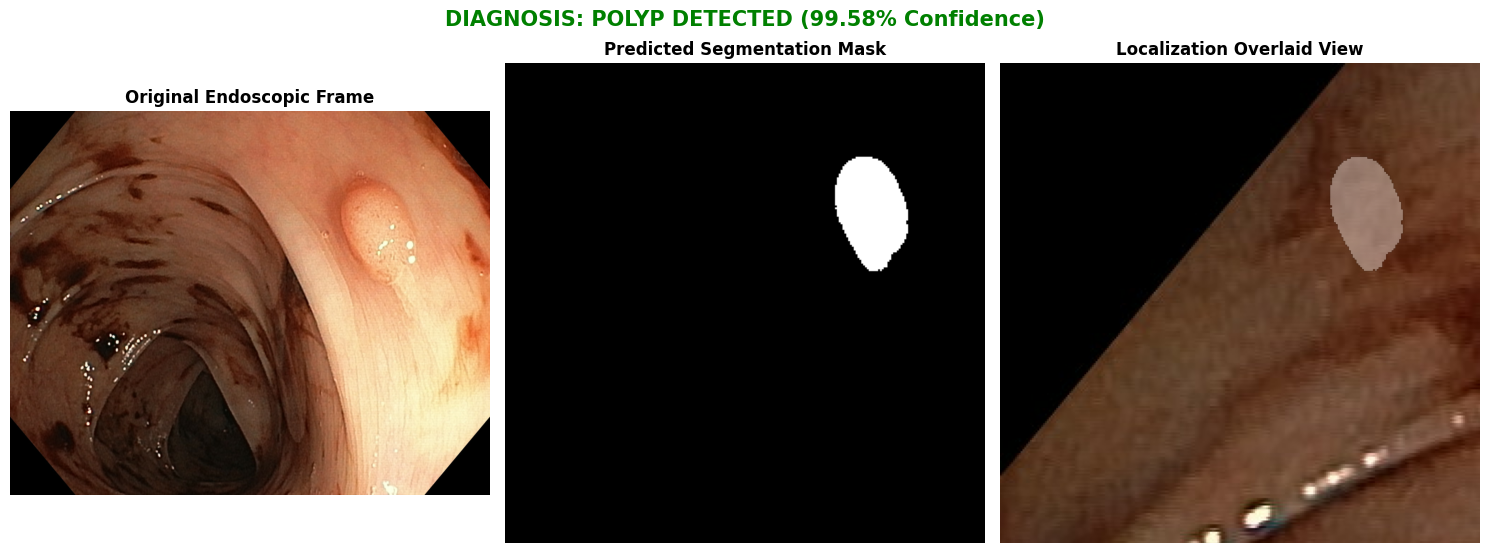

In [10]:
%matplotlib inline

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.utils import custom_object_scope

# ⚙️ কনফিগারেশনস
IMG_SIZE = 256  
model_path = "/mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unified_net/thesis_v3_sequential.keras"
image_path = "/mnt/c/development/Thesis/PolypSegmentationBasedClassification/DataSets/PolypGen2021_MultiCenterData_v2/imagesAll_positive/425OLCV1_100H0018.jpg"
# কাস্টম লেয়ার এবং ডামি ফাংশন রেজিস্ট্রেশন (মডেল লোড করার জন্য বাধ্যতামূলক)
@tf.keras.utils.register_keras_serializable()
class KerasPCCLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(KerasPCCLayer, self).__init__(**kwargs)
    def call(self, inputs):
        epsilon = 1e-8
        mean = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        std = tf.math.reduce_std(inputs, axis=-1, keepdims=True) + epsilon
        norm_inputs = (inputs - mean) / std
        pcc_matrix = tf.matmul(tf.expand_dims(norm_inputs, -1), tf.expand_dims(norm_inputs, 1))
        return tf.keras.layers.Flatten()(pcc_matrix)

def dice_coef(y_true, y_pred): return 0.0
def iou_metric(y_true, y_pred): return 0.0
def bce_dice_loss(y_true, y_pred): return 0.0

# 🔮 ইনফ্যারেন্স ইঞ্জিন ফাংশন
def run_unified_inference(model_path, image_path):
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"❌ Target ইমেজটি খুঁজে পাওয়া যায়নি: {image_path}")

    # ১. মডেল লোড করা
    print("⏳ Loading Unified Thesis Network Graph...")
    with custom_object_scope({
        'KerasPCCLayer': KerasPCCLayer, 
        'dice_coef': dice_coef, 
        'iou_metric': iou_metric, 
        'bce_dice_loss': bce_dice_loss
    }):
        model = tf.keras.models.load_model(model_path)
    print("✅ Model loaded successfully.")

    # ২. ইমেজ প্রি-প্রসেসিং (যা আপনি মিস করেছিলেন)
    raw_img = tf.io.read_file(image_path)
    decoded_img = tf.image.decode_image(raw_img, channels=3, expand_animations=False)
    resized_img = tf.image.resize(decoded_img, [IMG_SIZE, IMG_SIZE])
    normalized_img = tf.cast(resized_img, tf.float32) / 255.0
    input_tensor = tf.expand_dims(normalized_img, axis=0)  # Shape: [1, 256, 256, 3]

    # ৩. মডেল প্রেডিকশন
    print("🚀 Running forward pass...")
    pred_outputs = model.predict(input_tensor, verbose=0)
    
    pred_mask = pred_outputs[0][0]          # Segmentation Map [256, 256, 1]
    clf_probability = pred_outputs[1][0][0] # Classification Probability Scalar

    # ৪. মাস্ক ও ডায়াগনস্টিক টেক্সট প্রিপারেশন
    binary_mask = (pred_mask > 0.5).astype(np.uint8) * 255
    
    if clf_probability >= 0.5:
        diagnostic_text = f"DIAGNOSIS: POLYP DETECTED ({clf_probability * 100:.2f}% Confidence)"
        title_color = 'green'
    else:
        diagnostic_text = f"DIAGNOSIS: NON-POLYP ({ (1.0 - clf_probability) * 100:.2f}% Confidence)"
        title_color = 'red'

    # ৫. ম্যাটপ্লটলিব সাবপ্লট রেন্ডারিং (জুপাইটার ইনলাইন-ফ্রেন্ডলি)
    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    
    # Subplot 1: Original Image
    axes[0].imshow(decoded_img.numpy().astype("uint8"))
    axes[0].set_title("Original Endoscopic Frame", fontsize=12, fontweight='bold')
    axes[0].axis("off")
    
    # Subplot 2: Binary Mask
    axes[1].imshow(binary_mask.squeeze(), cmap='gray')
    axes[1].set_title("Predicted Segmentation Mask", fontsize=12, fontweight='bold')
    axes[1].axis("off")
    
    # Subplot 3: Red Overlay
    axes[2].imshow(decoded_img.numpy().astype("uint8"))
    masked_overlay = np.ma.masked_where(binary_mask.squeeze() == 0, binary_mask.squeeze())
    axes[2].imshow(masked_overlay, cmap='Reds', alpha=0.4)
    axes[2].set_title("Localization Overlaid View", fontsize=12, fontweight='bold')
    axes[2].axis("off")

    plt.suptitle(diagnostic_text, color=title_color, fontsize=15, fontweight='bold', y=0.96)
    plt.tight_layout()
    plt.show()

# রান করুন
run_unified_inference(model_path, image_path)

⏳ Loading Unified Thesis Network Graph...
✅ Model loaded successfully.
🚀 Running forward pass...


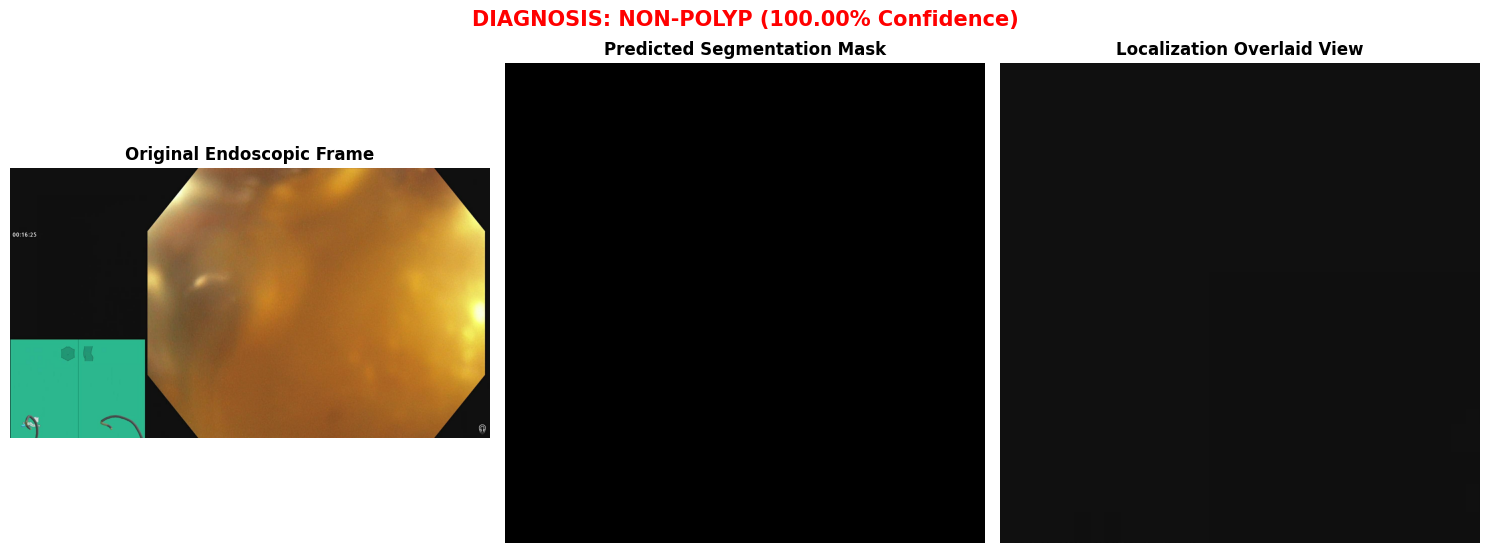

In [11]:
image_path = "/mnt/c/development/Thesis/PolypSegmentationBasedClassification/DataSets/PolypGen2021_MultiCenterData_v2/sequenceData/negativeOnly/seq10_neg/EndoCV2021_seq10_neg_40_endocv2021_negative_754.jpg"
run_unified_inference(model_path, image_path)